# Text to image with classifier-free guidance

**This is part 3 of the series, and it builds directly on [notebook 02](02-train-a-diffusion-model.ipynb), so I would recommend going through that one first.**

The model we trained in notebook 02 learned what flowers look like, but there was no way to tell it which flower to draw. You simply got whatever flower the starting noise happened to lead to. But what we usually want is to describe the image in words and get that image. So in this notebook, we give the model a caption with every image, so that at the end we can type "a red rose" and get something red and rose-like. We will also look at classifier-free guidance, the trick that makes a model follow its caption much more closely.

**The notebook expects one NVIDIA GPU. Training takes most of the time, about twenty minutes on an RTX 4080. The first run downloads the CLIP text encoder (about 1.7 GB) and the flower images (about 270 MB).**

## Install Dependencies

Same as notebook 02: Dew from GitHub with its `cuda13` and `streaming` extras.

In [ ]:
%pip install -q "dew-ml[cuda13,streaming] @ git+https://github.com/AshishKumar4/dew"

## Settings

As before, every number lives in this one cell. `UNCONDITIONAL_PROB` is the fraction of training captions we replace with an empty one; the guidance section explains why. `PROMPTS` are the captions we sample at the end, and `GUIDANCE_SCALES` are the guidance strengths we compare. We also train a bit longer than in notebook 02, 8,000 steps instead of 6,000.

In [1]:
import os

IMAGE_SIZE = 64
BATCH_SIZE = 64
STEPS = 8000
LEARNING_RATE = 3e-4
UNCONDITIONAL_PROB = 0.12
SAMPLE_STEPS = 40
PROMPTS = ["a red rose", "a yellow sunflower", "a white daisy", "a purple iris"]
GUIDANCE_SCALES = [1.0, 3.0, 6.0]
RUN_DIR = "runs/03-text-to-image"
SEED = 0

# The tutorial test sets DEW_TUTORIAL_SMOKE=1 to run every cell in minutes on a CPU.
if os.environ.get("DEW_TUTORIAL_SMOKE") == "1":
    BATCH_SIZE, STEPS, SAMPLE_STEPS = 8, 4, 4


In [2]:
import jax
import matplotlib.pyplot as plt
import numpy as np

print(jax.devices())

[CudaDevice(id=0)]


In [3]:
import textwrap

def show_images(images, titles, columns=4):
    rows = (len(images) + columns - 1) // columns
    figure, axes = plt.subplots(rows, columns, figsize=(columns * 1.8, rows * 2.1))
    for axis, image, title in zip(np.ravel(axes), images, titles):
        axis.imshow(image)
        axis.set_title(textwrap.fill(title, 22), fontsize=7)
        axis.axis("off")
    plt.tight_layout()
    plt.show()

## Turning text into numbers

A neural network can't read words, so a text encoder first turns each caption into a sequence of vectors. We use the text half of CLIP (ViT-L/14), from the paper ["Learning Transferable Visual Models From Natural Language Supervision" by Radford et al. (2021)](https://arxiv.org/abs/2103.00020). CLIP was trained to match captions with images, so its vectors already say something about what a caption looks like, which is exactly what we want here. We keep CLIP frozen; only the diffusion model trains.

The `InputSpec` now has a condition as well as the image. `Condition(encoder, field="text", unconditional="")` basically says: read tokens from the batch field `text`, encode them with CLIP, and use the empty caption as "no caption". The key `textcontext` is the keyword the model receives the encoded caption under.

In [4]:
from dew import Condition, Field, InputSpec
from dew.inputs import CLIPText

encoder = CLIPText.from_pretrained("openai/clip-vit-large-patch14")
inputs = InputSpec(
    sample=Field("image", (IMAGE_SIZE, IMAGE_SIZE, 3)),
    conditions={"textcontext": Condition(encoder, field="text", unconditional="")},
)
print("context length:", encoder.context)
print(inputs.tokenize(["a red rose"])["text"].keys())

/content/batch/job-1/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

Fetching 7 files:  14%|█▍        | 1/7 [00:00<00:01,  3.69it/s]

Fetching 7 files: 100%|██████████| 7/7 [00:00<00:00, 22.74it/s]

[dry-run] Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

...

[dry-run] Fetching 13 files: 100%|██████████| 13/13 [00:00<00:00, 50.30it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching 1 files: 100%|██████████| 1/1 [00:07<00:00,  7.06s/it]

Fetching 1 files: 100%|██████████| 1/1 [00:07<00:00,  7.06s/it]

context length: 77
dict_keys(['input_ids', 'attention_mask'])


## Captioned data

The data is the same Hugging Face copy of Oxford Flowers as in notebook 02, and every photo carries a caption written by an image captioning model ([BLIP](https://arxiv.org/abs/2201.12086)). Passing `tokenize=inputs.tokenize` to `load` turns each caption into CLIP tokens while the batch is being built, so the batches carry token arrays under `text` instead of strings.

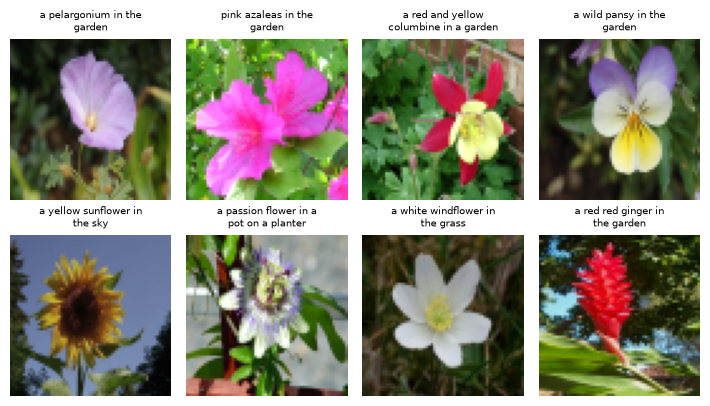

In [5]:
from dew.data import DataPartition, HFImages, Loading

data = HFImages(
    name="pranked03/flowers-blip-captions",
    image_size=IMAGE_SIZE,
    val_batches=0,
    loading=Loading(workers=0, threads=16, read_buffer=64),
).load(batch=BATCH_SIZE, tokenize=inputs.tokenize)

batch = next(iter(data.train(DataPartition())))
captions = encoder.captions(batch["text"])
show_images(batch["image"][:8], captions[:8])

## The model and the objective

The model is the same DiT from notebook 02, except that now it takes the caption vectors through the `textcontext` keyword and mixes them into every layer.

`DiffusionObjective` gets two new arguments. `unconditional_prob` makes it swap the caption for the empty one on 12% of training rows, and `guidance=CFG(3.0)` is how its previews sample. The CLIP weights ride along in the training state as frozen parameters, so they are saved in the checkpoint but never updated.

In [6]:
import optax
from dew import Checkpoints, LocalTracker, Trainer, models, presets
from dew.objectives.diffusion import DiffusionObjective
from dew.sampling import CFG, EulerAncestral

process = presets.EDM()()
model = models.build(
    "simple_dit",
    patch_size=4,
    emb_features=256,
    num_layers=6,
    num_heads=4,
    output_channels=3,
    dtype="bfloat16",
    attention_impl="auto",
)
objective = DiffusionObjective(
    model, process, inputs,
    unconditional_prob=UNCONDITIONAL_PROB,
    ema_decay=0.999,
    sampler=EulerAncestral(), guidance=CFG(3.0), steps=SAMPLE_STEPS,
)
trainer = Trainer(
    objective, optax.adamw(LEARNING_RATE),
    key=jax.random.key(SEED),
    checkpoints=Checkpoints(RUN_DIR),
    tracker=LocalTracker(f"{RUN_DIR}/tracking"),
)

## Training

Nothing new here: `fit` trains until `STEPS`, prints the loss every 1,000 steps and writes a checkpoint at the end, and then we plot the loss from the tracker, just like in notebook 02.

In [7]:
state = trainer.fit(data, steps=STEPS, log_every=1000, checkpoint_every=STEPS)

Training from step 0 to 8000 on {'data': 1, 'expert': 1, 'fsdp': 1, 'tensor': 1, 'sequence': 1, 'stage': 1} (1 process(es))


step 1000: loss 0.1122


step 2000: loss 0.1067


step 3000: loss 0.1043


step 4000: loss 0.0972


step 5000: loss 0.1118


step 6000: loss 0.0901


step 7000: loss 0.0928


step 8000: loss 0.0989


Goodput: first step after 50.49 s, 94.9% of the wall time in steps


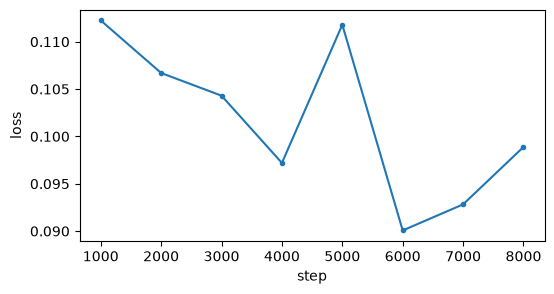

In [8]:
import json

rows = [json.loads(line) for line in open(f"{RUN_DIR}/tracking/scalars.jsonl")]
rows = [row for row in rows if "train/loss" in row["scalars"]]
plt.figure(figsize=(6, 3))
plt.plot([row["step"] for row in rows], [row["scalars"]["train/loss"] for row in rows], marker=".")
plt.xlabel("step")
plt.ylabel("loss")
plt.show()

## Classifier-free guidance

Now the interesting part. Because some captions were blanked during training, one model has actually learned two things: how to denoise a flower given its caption, and how to denoise a flower with no caption at all. At sampling time, we ask it both questions at every step and push the answer away from the uncaptioned one:

$\hat{\epsilon} = \epsilon_{\text{uncond}} + s \, (\epsilon_{\text{cond}} - \epsilon_{\text{uncond}})$

where:
- $\epsilon_{\text{cond}}$ is the model's prediction given the caption,
- $\epsilon_{\text{uncond}}$ is its prediction given the empty caption,
- $s$ is the guidance scale.

With $s = 1$ this is just the plain captioned prediction. The difference $\epsilon_{\text{cond}} - \epsilon_{\text{uncond}}$ is basically the direction the caption pulls the image in, and the scale says how far we follow it. Larger scales follow the caption harder and give up some variety in return. This is classifier-free guidance, from the paper ["Classifier-Free Diffusion Guidance" by Ho and Salimans (2022)](https://arxiv.org/abs/2207.12598), and `CFG(scale)` in Dew computes it.

*But why "classifier-free"? Well, the guidance that came before it, in the paper [Diffusion Models beat GANs on image synthesis](https://arxiv.org/abs/2105.05233), needed a separate classifier trained on noisy images, whose gradient pushed the sample towards the class we wanted. Here the same model plays both roles, so there is no classifier at all.*

`objective.pipeline(state)` packages the trained model, the process, the text encoder and the EMA weights into a `TextToImage` pipeline. Calling it with a list of prompts returns the images.

In [9]:
pipe = objective.pipeline(state)

rows = []
for scale in GUIDANCE_SCALES:
    out = pipe(PROMPTS * 2, steps=SAMPLE_STEPS, guidance=CFG(scale), sampler=EulerAncestral(), seed=1)
    rows.append(np.asarray(out.images))

Let's look at the results. Each row below is one guidance scale, from 1 at the top to 6 at the bottom. Each column is one prompt, and each prompt appears twice per row with different starting noise.

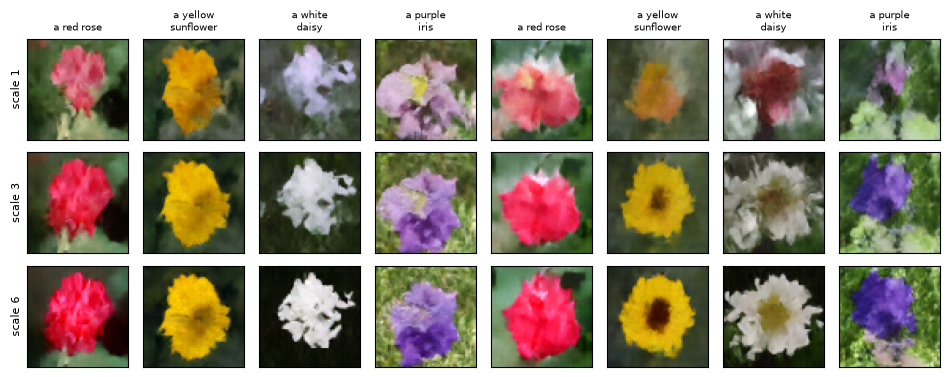

In [10]:
columns = len(PROMPTS) * 2
figure, axes = plt.subplots(len(GUIDANCE_SCALES), columns, figsize=(columns * 1.2, len(GUIDANCE_SCALES) * 1.3))
for row, (scale, images) in enumerate(zip(GUIDANCE_SCALES, rows)):
    for column in range(columns):
        axis = axes[row, column]
        axis.imshow(np.clip((images[column] + 1) / 2, 0, 1))
        axis.set_xticks([])
        axis.set_yticks([])
        if row == 0:
            axis.set_title(textwrap.fill((PROMPTS * 2)[column], 12), fontsize=7)
    axes[row, 0].set_ylabel(f"scale {scale:g}", fontsize=8)
plt.tight_layout()
plt.show()

When we ran this notebook, the colours at scale 1 only loosely followed the prompts: one "white daisy" came out dark red. At scale 3 every image had the colour its prompt asked for, and the sunflowers got a dark centre. At scale 6 the colours were the most saturated and the two samples of each prompt looked more alike, which is the variety that strong guidance gives up. Twenty minutes of training on 6,500 images is honestly not enough for sharp flowers, but the caption already steers the colour and the rough shape, which I think is pretty neat.

## Where to go next

`recipes/diffusion/train.py` runs this setup from the command line and writes `run.json` next to the checkpoints, so that `TextToImage.from_run(directory)` can rebuild the pipeline later. For larger images, `StableDiffusionVAE` in `dew.nn.autoencoders.sd_vae` lets the model denoise small latents instead of pixels, which is the idea behind the paper ["High-Resolution Image Synthesis with Latent Diffusion Models" by Rombach et al. (2022)](https://arxiv.org/abs/2112.10752). [Notebook 04](04-samplers-and-schedules.ipynb) compares the samplers.